# H13: Cropped Replication of H1, H2, H5

Repeats vessel density (H1), vessel morphology (H2), and follicle
vascularization (H5) analyses using **size-normalized images**.

Large images are cropped to ~5000 µm windows centered on the densest vessel
area (same crop as H12). This includes **HDL018 and HDL021** (15 samples
total, only HDL172 excluded).

**Goal:** Test whether genotype-associated patterns persist when all images
have comparable spatial extent.

In [1]:
import sys, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.spatial import cKDTree
from scipy.stats import linregress, spearmanr
from matplotlib.patches import Patch

from data_utils import (
    PROJECT, DATA_CSV, CODEX_CSV, CODEX_SAMPLES,
    GENO_ORDER, GENO_PALETTE, GENOTYPE_MAP, EXCLUDE_SAMPLES,
    extract_sample_id, get_regions, get_vessels,
    _CODEX_CLASS_MAP, _CODEX_REGION_MAP,
    full_stats_table, setup_style, save_figure, save_table,
)

setup_style()

In [2]:
# Load all data (include HDL018/HDL021, exclude only HDL172)
df_main = pd.read_csv(DATA_CSV)
df_main["Sample"] = df_main["Image"].apply(extract_sample_id)
df_main["Genotype"] = df_main["Sample"].map(GENOTYPE_MAP)
df_main["Platform"] = df_main["Sample"].apply(
    lambda s: "CODEX" if s in CODEX_SAMPLES else "Phenocycler")
df_main = df_main[df_main["Sample"] != "HDL172"]
df_main = df_main.dropna(subset=["Genotype"])

codex = pd.read_csv(CODEX_CSV)
codex["Classification"] = codex["Classification"].map(lambda c: _CODEX_CLASS_MAP.get(c, c))
codex["Parent"] = codex["Parent"].str.replace(
    r"Annotation \((\w+)\)",
    lambda m: f"Annotation ({_CODEX_REGION_MAP.get(m.group(1), m.group(1))})",
    regex=True)
codex["Sample"] = codex["Image"].apply(extract_sample_id)
codex["Genotype"] = codex["Sample"].map(GENOTYPE_MAP)
codex["Platform"] = "CODEX"
codex = codex.dropna(subset=["Genotype"])

df_all = pd.concat([df_main, codex], ignore_index=True)
df_all["Genotype"] = pd.Categorical(df_all["Genotype"], categories=GENO_ORDER, ordered=True)

print(f"Total annotations: {len(df_all):,}")
print(f"Samples: {sorted(df_all['Sample'].unique())}")

Total annotations: 483,145
Samples: ['1901HBMP004', 'HBMP006', 'HBMP007', 'HDL011', 'HDL018', 'HDL021', 'HDL043', 'HDL052', 'HDL053', 'HDL055', 'HDL063', 'HDL070', 'HDL073', 'HDL086', 'HDL098']


In [3]:
# Crop large images to ~5000 µm window (same logic + seed as H12)
CROP_SIZE = 5000
CROP_THRESHOLD = 6000

vessels_for_crop = df_all[df_all["Classification"] == "SmallVessel"]
rng_crop = np.random.default_rng(7)

crop_windows = {}  # sample -> (cx, cy) or None
for sample in sorted(df_all["Sample"].unique()):
    sv = vessels_for_crop[vessels_for_crop["Sample"] == sample]
    coords = sv[["Centroid X µm", "Centroid Y µm"]].values
    x_ext, y_ext = coords[:, 0].ptp(), coords[:, 1].ptp()

    if max(x_ext, y_ext) <= CROP_THRESHOLD:
        crop_windows[sample] = None  # no crop needed
        continue

    half = CROP_SIZE / 2
    x_lo_c = coords[:, 0].min() + half
    x_hi_c = coords[:, 0].max() - half
    y_lo_c = coords[:, 1].min() + half
    y_hi_c = coords[:, 1].max() - half
    x_lo_c = min(x_lo_c, x_hi_c)
    y_lo_c = min(y_lo_c, y_hi_c)

    best_count, best_cx, best_cy = 0, np.median(coords[:, 0]), np.median(coords[:, 1])
    for _ in range(500):
        cx = rng_crop.uniform(x_lo_c, max(x_hi_c, x_lo_c + 1))
        cy = rng_crop.uniform(y_lo_c, max(y_hi_c, y_lo_c + 1))
        in_box = ((coords[:, 0] >= cx - half) & (coords[:, 0] <= cx + half) &
                  (coords[:, 1] >= cy - half) & (coords[:, 1] <= cy + half))
        if in_box.sum() > best_count:
            best_count, best_cx, best_cy = in_box.sum(), cx, cy

    crop_windows[sample] = (best_cx, best_cy)

# Apply crop to full dataframe
def in_crop(row):
    window = crop_windows.get(row["Sample"])
    if window is None:
        return True
    cx, cy = window
    half = CROP_SIZE / 2
    return (abs(row["Centroid X µm"] - cx) <= half and
            abs(row["Centroid Y µm"] - cy) <= half)

mask = df_all.apply(in_crop, axis=1)
df = df_all[mask].copy()

print(f"After crop: {len(df):,} annotations (from {len(df_all):,})")
print(f"\nPer-sample counts:")
for s in sorted(df["Sample"].unique()):
    n_before = (df_all["Sample"] == s).sum()
    n_after = (df["Sample"] == s).sum()
    tag = "CROPPED" if crop_windows[s] is not None else "full"
    print(f"  {s:16s}  {n_after:6d} / {n_before:6d}  ({tag})")

After crop: 120,110 annotations (from 483,145)

Per-sample counts:
  1901HBMP004         5932 /   5932  (full)
  HBMP006             8863 /   8863  (full)
  HBMP007             3300 /   3300  (full)
  HDL011              8491 /  34567  (CROPPED)
  HDL018              5409 /   5409  (full)
  HDL021             11732 /  58452  (CROPPED)
  HDL043              4936 /  29559  (CROPPED)
  HDL052              6792 /  16426  (CROPPED)
  HDL053             10941 /  71018  (CROPPED)


  HDL055             14863 /  71143  (CROPPED)
  HDL063             10280 /  90676  (CROPPED)
  HDL070             10261 /  32597  (CROPPED)
  HDL073              5108 /   5108  (full)
  HDL086              7857 /  44750  (CROPPED)
  HDL098              5345 /   5345  (full)


---
## H1 (Cropped): Follicle Vessel Density by Genotype

Per-annotation density computed the same way as the original H1:
SmallVessels parented to Follicle are assigned to nearest Follicle
annotation centroid via cKDTree.

In [4]:
# Per-annotation follicle vessel density (same as H1 compute_per_region_density)
records = []
for image in df["Image"].unique():
    img_df = df[df["Image"] == image]
    sample = img_df["Sample"].iloc[0]
    genotype = str(img_df["Genotype"].iloc[0])
    platform = "CODEX" if sample in CODEX_SAMPLES else "Phenocycler"

    regions = img_df[img_df["Classification"] == "Follicle"].copy()
    if regions.empty:
        continue

    reg_coords = regions[["Centroid X µm", "Centroid Y µm"]].values
    reg_ids = regions["Object ID"].values
    reg_areas = regions["Area µm^2"].values

    vessels = img_df[img_df["Classification"] == "SmallVessel"].copy()
    vessels["Region"] = vessels["Parent"].str.extract(r"Annotation \((\w+)\)")
    fol_vessels = vessels[vessels["Region"] == "Follicle"]

    vessel_counts = np.zeros(len(regions), dtype=int)
    if not fol_vessels.empty:
        tree = cKDTree(reg_coords)
        ves_coords = fol_vessels[["Centroid X µm", "Centroid Y µm"]].values
        _, indices = tree.query(ves_coords)
        for idx in indices:
            vessel_counts[idx] += 1

    for i in range(len(regions)):
        area_mm2 = reg_areas[i] / 1e6
        records.append({
            "Image": image, "Sample": sample, "Genotype": genotype,
            "Platform": platform, "Object_ID": reg_ids[i],
            "Region_Area_um2": reg_areas[i], "Region_Area_mm2": area_mm2,
            "Vessel_Count": vessel_counts[i],
            "Density_per_mm2": vessel_counts[i] / area_mm2 if area_mm2 > 0 else 0,
        })

fol_per = pd.DataFrame(records)
fol_per["Genotype"] = pd.Categorical(fol_per["Genotype"], categories=GENO_ORDER, ordered=True)

print(f"Follicle annotations: {len(fol_per)} across {fol_per['Sample'].nunique()} samples")
print(f"\nPer-genotype summary:")
print(fol_per.groupby("Genotype", observed=True).agg(
    n_annotations=("Object_ID", "count"),
    n_samples=("Sample", "nunique"),
    median_density=("Density_per_mm2", "median"),
).to_string())

Follicle annotations: 734 across 15 samples

Per-genotype summary:
          n_annotations  n_samples  median_density
Genotype                                          
C/C                 130          4      305.860218
C/T                 336          8      240.278722
T/T                 268          3      645.577565


Saved: analysis/figures/H13_H1_follicle_density.png


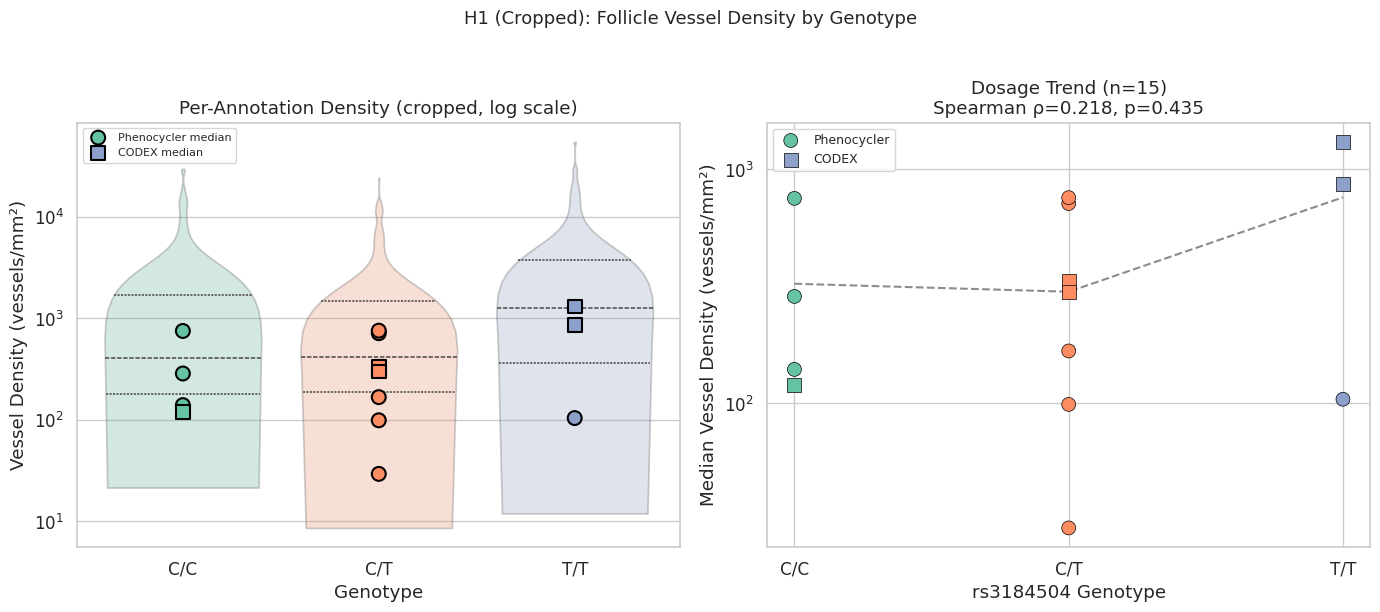

In [5]:
# Violin + per-sample medians (log-scale y-axis)
markers = {"Phenocycler": "o", "CODEX": "s"}
sample_med = fol_per.groupby(["Sample", "Genotype", "Platform"], observed=True)[
    "Density_per_mm2"].median().reset_index()

# Drop zero-density annotations for log scale
fol_plot = fol_per[fol_per["Density_per_mm2"] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
sns.violinplot(data=fol_plot, x="Genotype", y="Density_per_mm2", order=GENO_ORDER,
               palette=GENO_PALETTE, inner="quartile", alpha=0.3, ax=ax, cut=0)
for plat, mkr in markers.items():
    sub = sample_med[sample_med["Platform"] == plat]
    x_pos = sub["Genotype"].astype(str).map({g: i for i, g in enumerate(GENO_ORDER)})
    ax.scatter(x_pos, sub["Density_per_mm2"], marker=mkr, s=100,
               c=[GENO_PALETTE[g] for g in sub["Genotype"]], edgecolors="black",
               linewidths=1.5, zorder=10, label=f"{plat} median")
ax.set_yscale("log")
ax.set_ylabel("Vessel Density (vessels/mm²)")
ax.set_title("Per-Annotation Density (cropped, log scale)")
ax.legend(fontsize=8)

# Dosage trend (log-scale)
ax = axes[1]
sample_med["Geno_Ordinal"] = sample_med["Genotype"].astype(str).map(
    {"C/C": 0, "C/T": 1, "T/T": 2})
rho, sp_p = spearmanr(sample_med["Geno_Ordinal"], sample_med["Density_per_mm2"])
for plat, mkr in markers.items():
    sub = sample_med[sample_med["Platform"] == plat]
    ax.scatter(sub["Geno_Ordinal"], sub["Density_per_mm2"], marker=mkr, s=100,
               c=[GENO_PALETTE[g] for g in sub["Genotype"]],
               edgecolors="black", linewidths=0.5, label=plat, zorder=5)
means = sample_med.groupby("Geno_Ordinal")["Density_per_mm2"].mean()
ax.plot(means.index, means.values, "k--", alpha=0.5, linewidth=1.5)
ax.set_yscale("log")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(GENO_ORDER)
ax.set_xlabel("rs3184504 Genotype")
ax.set_ylabel("Median Vessel Density (vessels/mm²)")
ax.set_title(f"Dosage Trend (n={len(sample_med)})\nSpearman ρ={rho:.3f}, p={sp_p:.3f}")
ax.legend(fontsize=9)

fig.suptitle("H1 (Cropped): Follicle Vessel Density by Genotype", fontsize=13, y=1.02)
fig.tight_layout()
save_figure(fig, "H13_H1_follicle_density")
plt.show()

In [6]:
# Nonparametric stats on per-sample medians (same as H2/H5)
h1_stats = []

# All samples
h1_stats.append(full_stats_table(sample_med, "Density_per_mm2",
                                  label="Follicle density (All, n=15)"))

# Phenocycler-only
pc_med = sample_med[sample_med["Platform"] == "Phenocycler"]
if pc_med["Sample"].nunique() >= 3:
    h1_stats.append(full_stats_table(pc_med, "Density_per_mm2",
                                      label="Follicle density (PC-only)"))

h1_stats_df = pd.concat(h1_stats, ignore_index=True)
save_table(h1_stats_df, "H13_H1_stats")
display(h1_stats_df)

Saved: analysis/tables/H13_H1_stats.csv


,Test,Metric,Statistic,p,Effect_Size
0,Kruskal-Wallis,"Follicle density (All, n=15)",1.762500,0.414265,
1,Mann-Whitney (C/C vs C/T),"Follicle density (All, n=15)",17.000000,0.933333,r=-0.062
2,Mann-Whitney (C/C vs T/T),"Follicle density (All, n=15)",4.000000,0.628571,r=0.333
3,Mann-Whitney (C/T vs T/T),"Follicle density (All, n=15)",5.000000,0.193939,r=0.583
4,Spearman dosage,"Follicle density (All, n=15)",0.218227,0.434595,rho=0.218
5,Kruskal-Wallis,Follicle density (PC-only),1.145455,0.563985,
6,Mann-Whitney (C/C vs C/T),Follicle density (PC-only),12.000000,0.547619,r=-0.333
7,Mann-Whitney (C/C vs T/T),Follicle density (PC-only),3.000000,0.500000,r=-1.000
8,Mann-Whitney (C/T vs T/T),Follicle density (PC-only),3.000000,1.000000,r=0.000
9,Spearman dosage,Follicle density (PC-only),-0.353706,0.316018,rho=-0.354


---
## H2 (Cropped): Vessel Morphology by Genotype

SmallVessel shape metrics across all regions, then Follicle-stratified.

In [7]:
# All SmallVessels in cropped data
all_sv = df[df["Classification"] == "SmallVessel"].copy()
all_sv["Elongation"] = all_sv["Max diameter µm"] / all_sv["Min diameter µm"].replace(0, np.nan)
all_sv["Region"] = all_sv["Parent"].str.extract(r"Annotation \((\w+)\)")
all_sv["Platform"] = all_sv["Sample"].apply(
    lambda s: "CODEX" if s in CODEX_SAMPLES else "Phenocycler")

MORPH_COLS = ["Area µm^2", "Circularity", "Solidity", "Elongation"]
MORPH_LABELS = ["Area (µm²)", "Circularity", "Solidity", "Elongation"]

print(f"Total SmallVessels (cropped): {len(all_sv):,}")
print(f"By region: {all_sv['Region'].value_counts().to_dict()}")

# Per-image medians (unit of analysis)
img_morph = all_sv.groupby(["Image", "Sample", "Genotype"], observed=True)[MORPH_COLS].median().reset_index()
fol_sv = all_sv[all_sv["Region"] == "Follicle"]
fol_img = fol_sv.groupby(["Image", "Sample", "Genotype"], observed=True)[MORPH_COLS].median().reset_index()

Total SmallVessels (cropped): 115,919
By region: {'RedPulp': 95488, 'Follicle': 8074, 'PALS': 8004, 'Trabeculae': 4093, 'LargeVessel': 97}


Saved: analysis/figures/H13_H2_morphology_all.png


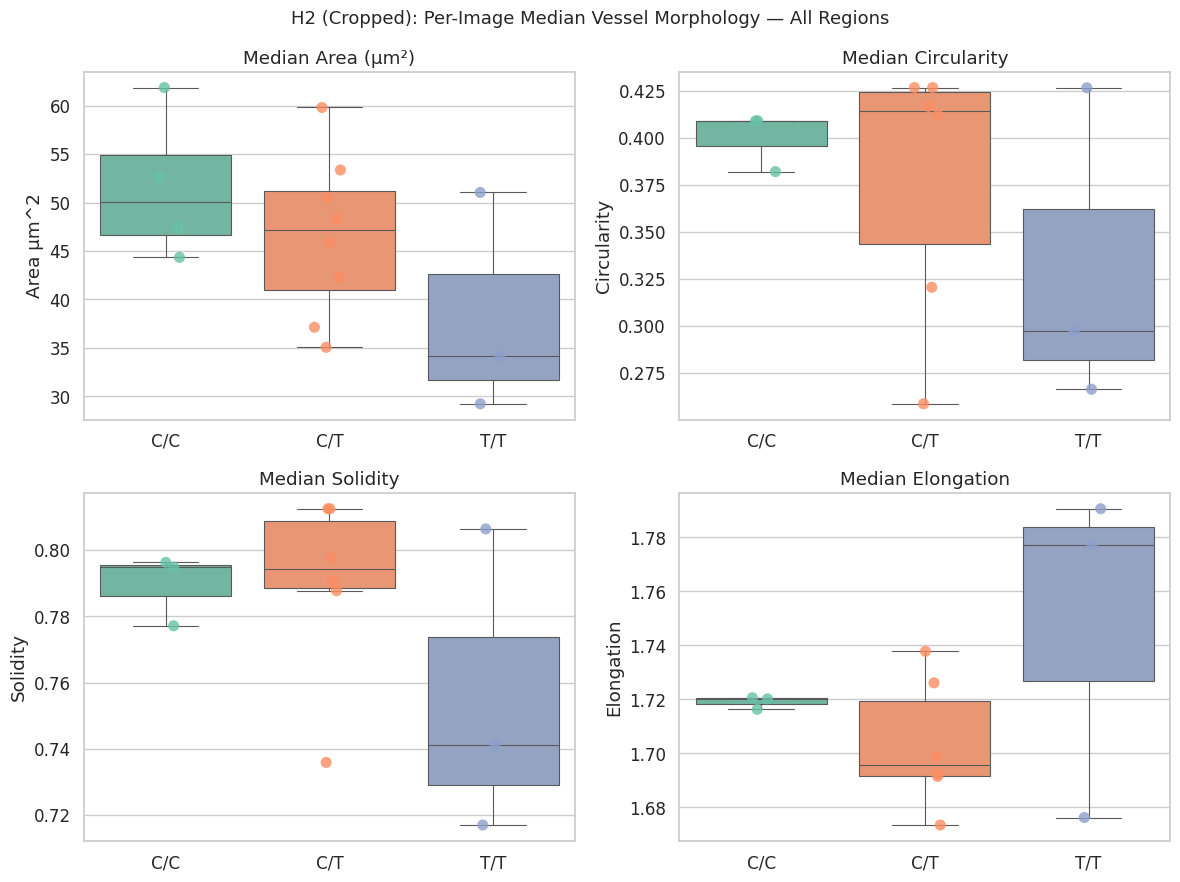

In [8]:
# Per-image median morphology by genotype — all regions
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, col, label in zip(axes.flat, MORPH_COLS, MORPH_LABELS):
    sns.boxplot(data=img_morph, x="Genotype", y=col, order=GENO_ORDER,
                palette=GENO_PALETTE, ax=ax, linewidth=0.8, fliersize=0)
    sns.stripplot(data=img_morph, x="Genotype", y=col, order=GENO_ORDER,
                  palette=GENO_PALETTE, ax=ax, size=8, alpha=0.8)
    ax.set_title(f"Median {label}")
    ax.set_xlabel("")

fig.suptitle("H2 (Cropped): Per-Image Median Vessel Morphology — All Regions", fontsize=13)
fig.tight_layout()
save_figure(fig, "H13_H2_morphology_all")
plt.show()

Saved: analysis/figures/H13_H2_morphology_follicle.png


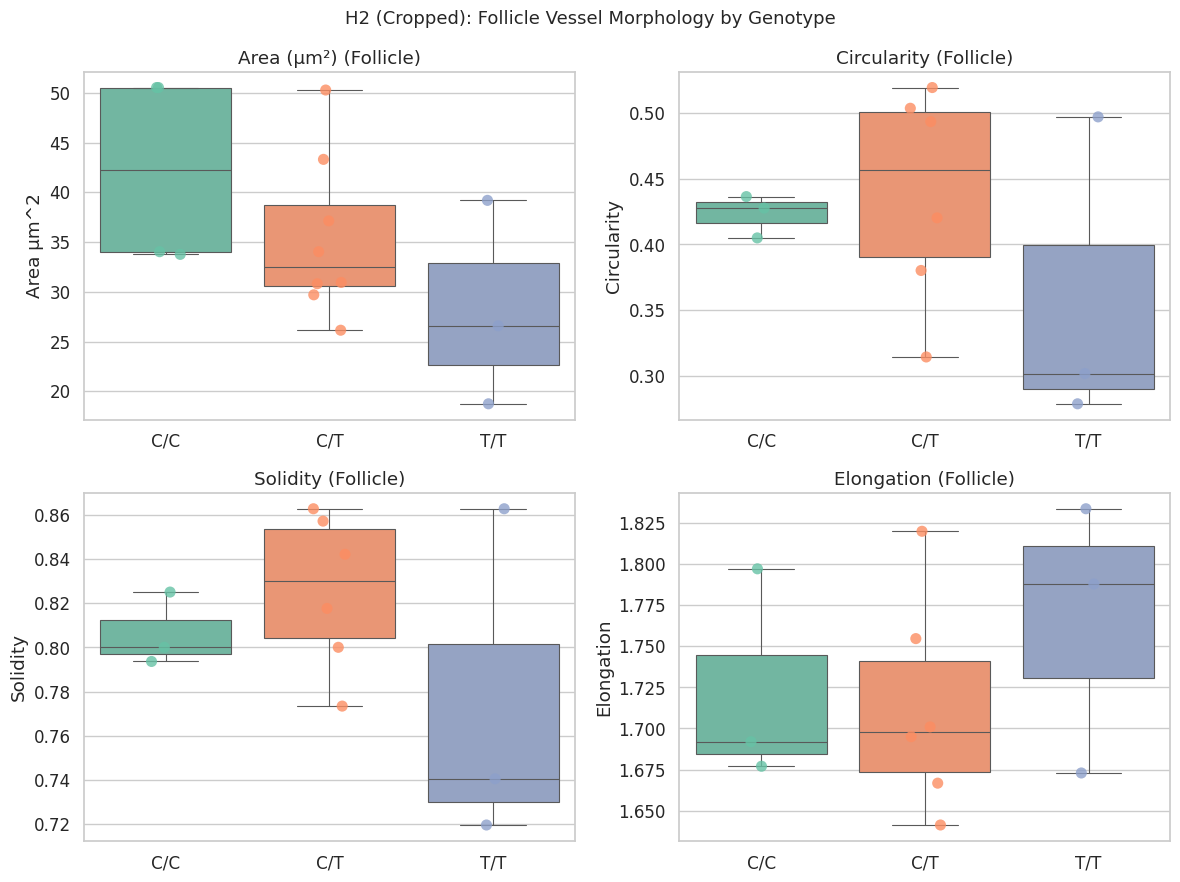

In [9]:
# Follicle-stratified morphology
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, col, label in zip(axes.flat, MORPH_COLS, MORPH_LABELS):
    sns.boxplot(data=fol_img, x="Genotype", y=col, order=GENO_ORDER,
                palette=GENO_PALETTE, ax=ax, linewidth=0.8, fliersize=0)
    sns.stripplot(data=fol_img, x="Genotype", y=col, order=GENO_ORDER,
                  palette=GENO_PALETTE, ax=ax, size=8, alpha=0.8)
    ax.set_title(f"{label} (Follicle)")
    ax.set_xlabel("")

fig.suptitle("H2 (Cropped): Follicle Vessel Morphology by Genotype", fontsize=13)
fig.tight_layout()
save_figure(fig, "H13_H2_morphology_follicle")
plt.show()

In [10]:
# Stats for morphology
h2_stats = []
for col, label in zip(MORPH_COLS, MORPH_LABELS):
    h2_stats.append(full_stats_table(img_morph, col, label=f"{label} (all regions)"))
    if len(fol_img) >= 3:
        h2_stats.append(full_stats_table(fol_img, col, label=f"{label} (Follicle)"))

h2_stats_df = pd.concat(h2_stats, ignore_index=True)
save_table(h2_stats_df, "H13_H2_stats")

# Show significant results
sig = h2_stats_df[(h2_stats_df["p"] < 0.1) & (h2_stats_df["p"] != "")]
if len(sig) > 0:
    print("Notable results (p < 0.1):")
    display(sig)
else:
    print("No results with p < 0.1")
display(h2_stats_df)

Saved: analysis/tables/H13_H2_stats.csv
Notable results (p < 0.1):


,Test,Metric,Statistic,p,Effect_Size
9,Spearman dosage,Area (µm²) (Follicle),-0.490412,0.063457,rho=-0.490


,Test,Metric,Statistic,p,Effect_Size
0,Kruskal-Wallis,Area (µm²) (all regions),2.685417,0.261137,
1,Mann-Whitney (C/C vs C/T),Area (µm²) (all regions),21.000000,0.460606,r=-0.312
2,Mann-Whitney (C/C vs T/T),Area (µm²) (all regions),10.000000,0.228571,r=-0.667
3,Mann-Whitney (C/T vs T/T),Area (µm²) (all regions),18.000000,0.278788,r=-0.500
4,Spearman dosage,Area (µm²) (all regions),-0.428589,0.110944,rho=-0.429
5,Kruskal-Wallis,Area (µm²) (Follicle),3.391801,0.183434,
6,Mann-Whitney (C/C vs C/T),Area (µm²) (Follicle),24.500000,0.172722,r=-0.531
7,Mann-Whitney (C/C vs T/T),Area (µm²) (Follicle),10.000000,0.211798,r=-0.667
8,Mann-Whitney (C/T vs T/T),Area (µm²) (Follicle),17.000000,0.375758,r=-0.417
9,Spearman dosage,Area (µm²) (Follicle),-0.490412,0.063457,rho=-0.490


---
## H5 (Cropped): Follicle Vascularization — Area vs Vessel Count

Assign each follicle-parented SmallVessel to its nearest follicle annotation
via cKDTree, then examine the scaling relationship.

In [11]:
# Assign vessels to follicles (same logic as H5)
all_assigned = []
for image in df["Image"].unique():
    img_df = df[df["Image"] == image]
    follicles = img_df[img_df["Classification"] == "Follicle"].copy()
    vessels_img = img_df[img_df["Classification"] == "SmallVessel"].copy()
    vessels_img["Region"] = vessels_img["Parent"].str.extract(r"Annotation \((\w+)\)")
    fol_v = vessels_img[vessels_img["Region"] == "Follicle"].copy()

    if follicles.empty or fol_v.empty:
        continue

    fol_coords = follicles[["Centroid X µm", "Centroid Y µm"]].values
    tree = cKDTree(fol_coords)
    ves_coords = fol_v[["Centroid X µm", "Centroid Y µm"]].values
    _, indices = tree.query(ves_coords)

    fol_v = fol_v.copy()
    fol_v["Follicle_ID"] = follicles["Object ID"].values[indices]
    fol_v["Follicle_Area"] = follicles["Area µm^2"].values[indices]
    all_assigned.append(fol_v)

fol_vessels = pd.concat(all_assigned, ignore_index=True) if all_assigned else pd.DataFrame()

# Per-follicle aggregation
regions = df[df["Classification"] == "Follicle"][
    ["Image", "Sample", "Genotype", "Object ID", "Area µm^2"]].copy()
regions.rename(columns={"Object ID": "Follicle_ID", "Area µm^2": "Follicle_Area"}, inplace=True)
regions["Follicle_Area_mm2"] = regions["Follicle_Area"] / 1e6

if not fol_vessels.empty:
    vc = fol_vessels.groupby("Follicle_ID").size().reset_index(name="Vessel_Count")
    per_fol = regions.merge(vc, on="Follicle_ID", how="left")
else:
    per_fol = regions.copy()
    per_fol["Vessel_Count"] = 0

per_fol["Vessel_Count"] = per_fol["Vessel_Count"].fillna(0).astype(int)
per_fol["Vessel_Density"] = per_fol["Vessel_Count"] / per_fol["Follicle_Area_mm2"]
per_fol["Genotype"] = pd.Categorical(per_fol["Genotype"], categories=GENO_ORDER, ordered=True)

print(f"Total follicles: {len(per_fol)} ({(per_fol['Vessel_Count'] == 0).sum()} with 0 vessels)")
print(f"Correlation (area vs count): r={np.corrcoef(per_fol['Follicle_Area'], per_fol['Vessel_Count'])[0,1]:.3f}")

Total follicles: 734 (169 with 0 vessels)
Correlation (area vs count): r=0.707


Saved: analysis/figures/H13_H5_area_vs_count.png


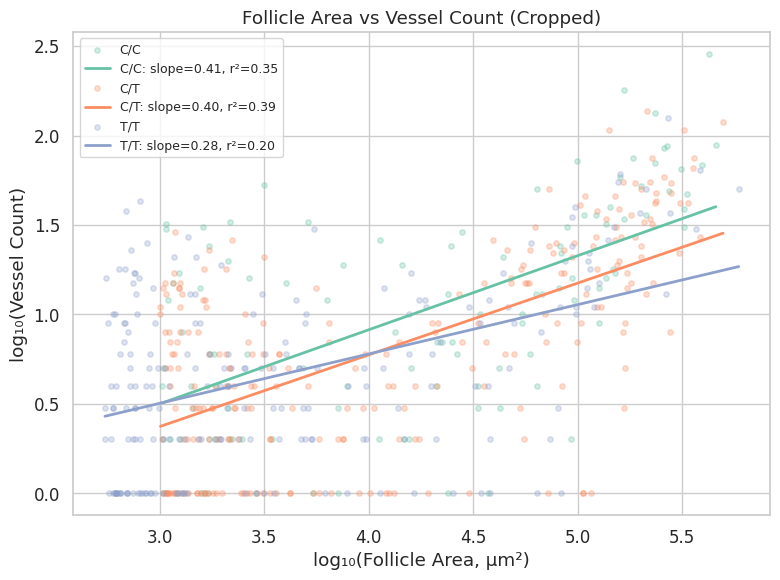

In [12]:
# Log-log area vs count with per-genotype regression
plot_fol = per_fol[per_fol["Vessel_Count"] > 0].copy()
plot_fol["log_area"] = np.log10(plot_fol["Follicle_Area"])
plot_fol["log_count"] = np.log10(plot_fol["Vessel_Count"])

fig, ax = plt.subplots(figsize=(8, 6))
for geno in GENO_ORDER:
    gd = plot_fol[plot_fol["Genotype"] == geno]
    ax.scatter(gd["log_area"], gd["log_count"], color=GENO_PALETTE[geno],
               alpha=0.3, s=15, label=geno)
    if len(gd) > 2:
        slope, intercept, r, p, se = linregress(gd["log_area"], gd["log_count"])
        x_line = np.linspace(gd["log_area"].min(), gd["log_area"].max(), 50)
        ax.plot(x_line, slope * x_line + intercept, color=GENO_PALETTE[geno],
                linewidth=2, label=f"{geno}: slope={slope:.2f}, r²={r**2:.2f}")

ax.set_xlabel("log₁₀(Follicle Area, µm²)")
ax.set_ylabel("log₁₀(Vessel Count)")
ax.set_title("Follicle Area vs Vessel Count (Cropped)")
ax.legend(fontsize=9)
fig.tight_layout()
save_figure(fig, "H13_H5_area_vs_count")
plt.show()

Saved: analysis/figures/H13_H5_slopes_density.png


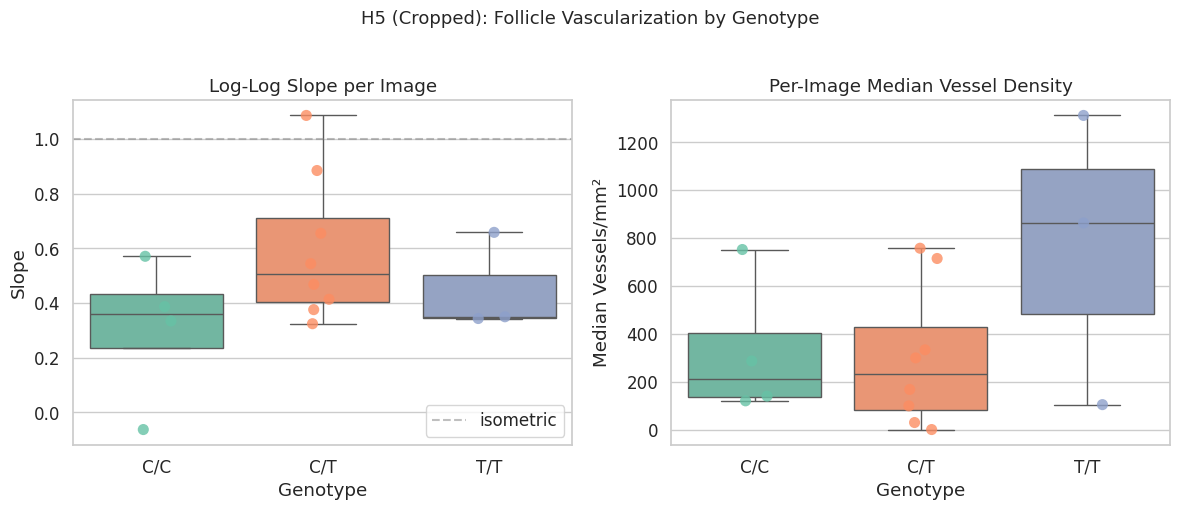

In [13]:
# Per-image slopes + per-follicle density
slopes = []
for (image, sample, geno), group in plot_fol.groupby(
        ["Image", "Sample", "Genotype"], observed=True):
    if len(group) < 5:
        continue
    slope, intercept, r, p, se = linregress(group["log_area"], group["log_count"])
    slopes.append({"Image": image, "Sample": sample, "Genotype": geno,
                   "Slope": slope, "R_squared": r**2, "N_follicles": len(group)})

slopes_df = pd.DataFrame(slopes)

img_density = per_fol.groupby(["Image", "Sample", "Genotype"], observed=True)[
    "Vessel_Density"].median().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
sns.boxplot(data=slopes_df, x="Genotype", y="Slope", order=GENO_ORDER,
            palette=GENO_PALETTE, ax=ax, fliersize=0)
sns.stripplot(data=slopes_df, x="Genotype", y="Slope", order=GENO_ORDER,
              palette=GENO_PALETTE, ax=ax, size=8, alpha=0.8)
ax.axhline(1, color="gray", linestyle="--", alpha=0.5, label="isometric")
ax.set_title("Log-Log Slope per Image")
ax.set_ylabel("Slope")
ax.legend()

ax = axes[1]
sns.boxplot(data=img_density, x="Genotype", y="Vessel_Density", order=GENO_ORDER,
            palette=GENO_PALETTE, ax=ax, fliersize=0)
sns.stripplot(data=img_density, x="Genotype", y="Vessel_Density", order=GENO_ORDER,
              palette=GENO_PALETTE, ax=ax, size=8, alpha=0.8)
ax.set_title("Per-Image Median Vessel Density")
ax.set_ylabel("Median Vessels/mm²")

fig.suptitle("H5 (Cropped): Follicle Vascularization by Genotype", fontsize=13, y=1.02)
fig.tight_layout()
save_figure(fig, "H13_H5_slopes_density")
plt.show()

In [14]:
# H5 stats
h5_stats = []
h5_stats.append(full_stats_table(img_density, "Vessel_Density",
                                  label="Per-image median vessel density"))
if len(slopes_df) >= 3:
    h5_stats.append(full_stats_table(slopes_df, "Slope",
                                      label="Log-log regression slope"))

h5_stats_df = pd.concat(h5_stats, ignore_index=True)
save_table(h5_stats_df, "H13_H5_stats")
display(h5_stats_df)

save_table(slopes_df.round(4), "H13_H5_regression_slopes")

Saved: analysis/tables/H13_H5_stats.csv


,Test,Metric,Statistic,p,Effect_Size
0,Kruskal-Wallis,Per-image median vessel density,1.762500,0.414265,
1,Mann-Whitney (C/C vs C/T),Per-image median vessel density,17.000000,0.933333,r=-0.062
2,Mann-Whitney (C/C vs T/T),Per-image median vessel density,4.000000,0.628571,r=0.333
3,Mann-Whitney (C/T vs T/T),Per-image median vessel density,5.000000,0.193939,r=0.583
4,Spearman dosage,Per-image median vessel density,0.218227,0.434595,rho=0.218
5,Kruskal-Wallis,Log-log regression slope,2.216667,0.330109,
6,Mann-Whitney (C/C vs C/T),Log-log regression slope,8.000000,0.214141,r=0.500
7,Mann-Whitney (C/C vs T/T),Log-log regression slope,4.000000,0.628571,r=0.333
8,Mann-Whitney (C/T vs T/T),Log-log regression slope,16.000000,0.496970,r=-0.333
9,Spearman dosage,Log-log regression slope,0.192669,0.491481,rho=0.193


Saved: analysis/tables/H13_H5_regression_slopes.csv


---
## Summary

This notebook replicates the core analyses from H1 (vessel density), H2
(vessel morphology), and H5 (follicle vascularization) using size-normalized
images. Large images are cropped to ~5000 µm windows to match smaller CODEX
tissue sections.

**Key comparisons vs originals:**
- H1: Are follicle density genotype trends preserved after cropping?
- H2: Do morphological differences persist at matched spatial extent?
- H5: Are area-count scaling slopes consistent in cropped windows?

Including HDL018 and HDL021 (normally excluded) expands the C/T group from
4 to 8 samples, improving statistical power for the heterozygous comparison.